In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, PrecisionRecallDisplay

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [11]:
print(" Loading dataset...")
df = pd.read_csv('creditcard.csv')

print(f" Data loaded successfully. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
print("\n Checking target distribution imbalance:")
print(df['Class'].value_counts())
print(f"Fraud Percentage: {df['Class'].value_counts(normalize=True)[1]*100:.3f}%")

 Loading dataset...
 Data loaded successfully. Shape: 284807 rows, 31 columns.

 Checking target distribution imbalance:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud Percentage: 0.173%


In [12]:
print("\n Engineering features...")


 Engineering features...


In [13]:
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

In [14]:
X = df.drop(['Time', 'Amount', 'Class'], axis=1)
y = df['Class']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f" Training split: {X_train.shape[0]} samples. Testing split: {X_test.shape[0]} samples.")

 Training split: 199364 samples. Testing split: 85443 samples.


In [16]:
print("\n Applying SMOTE to resolve class imbalance inside the training set...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f" New balanced training target distribution:")
print(y_train_res.value_counts())


 Applying SMOTE to resolve class imbalance inside the training set...
 New balanced training target distribution:
Class
0    199020
1    199020
Name: count, dtype: int64


In [18]:
print("\n Training Random Forest Classifier (this may take 1-2 minutes)...")
# Using n_jobs=-1 utilizes all available CPU cores to boost execution speeds
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_res, y_train_res)
print(" Model training completed.")


 Training Random Forest Classifier (this may take 1-2 minutes)...
 Model training completed.


In [20]:
print("\n Evaluating system performance on untouched test records...")
y_pred = model.predict(X_test)

print("\n Confusion Matrix Breakdown:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n Detailed Classification Performance Profile:")
print(classification_report(y_test, y_pred))


 Evaluating system performance on untouched test records...

 Confusion Matrix Breakdown:
[[85277    18]
 [   32   116]]

 Detailed Classification Performance Profile:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.78      0.82       148

    accuracy                           1.00     85443
   macro avg       0.93      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443




 Generating evaluation visualizations...


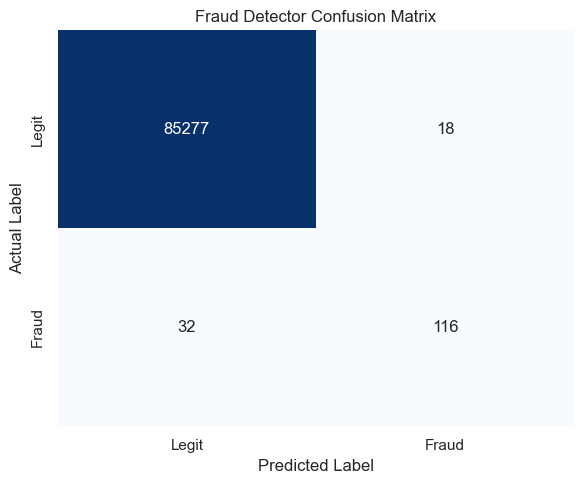

In [21]:
print("\n Generating evaluation visualizations...")

# Figure 1: Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Fraud Detector Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

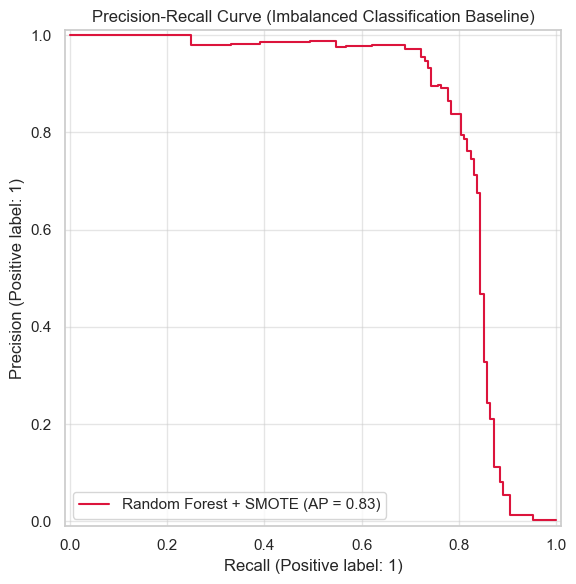


 Pipeline finished successfully!


In [22]:
plt.figure(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, name="Random Forest + SMOTE", color="crimson"
)
plt.title("Precision-Recall Curve (Imbalanced Classification Baseline)")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

print("\n Pipeline finished successfully!")

In [23]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [24]:
import sys
!{sys.executable} -m pip install streamlit imbalanced-learn

In [25]:
import streamlit as st
import imblearn
print("Success! Both tools are ready to use.")

Success! Both tools are ready to use.


In [2]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, PrecisionRecallDisplay

st.set_page_config(page_title="Fraud Detection Dashboard", layout="wide")
st.title(" Real-Time Credit Card Fraud Detection System")

@st.cache_data
def load_data():
    return pd.read_csv('creditcard.csv')

with st.spinner(" Loading dataset..."):
    df = load_data()
st.success(" Dataset loaded successfully!")

st.sidebar.header(" Pipeline Settings")
apply_smote = st.sidebar.checkbox("Apply SMOTE Data Balancing", value=True)
n_estimators = st.sidebar.slider("Number of Decision Trees", min_value=10, max_value=150, value=50, step=10)

col1, col2, col3 = st.columns(3)
col1.metric("Total Transactions", f"{len(df):,}")
col2.metric("Actual Fraud Cases", f"{df['Class'].sum():,}")
col3.metric("Percentage of Fraud", f"{(df['Class'].sum() / len(df)) * 100:.3f}%")

st.write(" Sample Transaction Data Rows")
st.dataframe(df.head(5))

if st.sidebar.button(" Train Machine Learning Model"):
    st.write("---")
    st.write(" Running Data Pipeline...")
    
    scaler = StandardScaler()
    df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
    X = df.drop(['Time', 'Amount', 'Class'], axis=1)
    y = df['Class']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    if apply_smote:
        st.info(" Applying SMOTE...")
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    st.success(" Model Training Complete!")
    
    vis_col1, vis_col2 = st.columns(2)
    with vis_col1:
        st.write(" Confusion Matrix")
        cm = confusion_matrix(y_test, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], ax=ax)
        st.pyplot(fig)
        
    with vis_col2:
        st.write(" Precision-Recall Curve")
        fig, ax = plt.subplots(figsize=(6, 4.6))
        PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, color="crimson")
        plt.grid(True, alpha=0.5)
        st.pyplot(fig)

Writing app.py


In [3]:
import sys
!{sys.executable} -m streamlit run app.py

^C


In [4]:
import sys
!{sys.executable} -m streamlit run app.py --server.port 8080 --server.headless true

^C


In [5]:
import sys
!{sys.executable} -m streamlit run app.py --server.port 8080 --server.headless true

2026-06-09 03:48:09.158 Port 8080 is already in use


In [ ]:
import sys
!{sys.executable} -m streamlit run app.py --server.port 8999 --server.headless true